# User Experience Analysis

## Objective

To analyze the overall user experience by evaluating key network performance metrics such as TCP retransmission, RTT, throughput, and handset type. The analysis aims to identify patterns across users and handsets, compare experience levels, and segment customers into different experience groups using K-Means clustering.

## Import Libraries & Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import KMeans

In [2]:
df_exp = pd.read_csv( "C:\\Users\\ijish\\Downloads\\telcom_data (2).xlsx - Sheet1.csv" ) 
print("Dataset shape:", df_exp.shape)

Dataset shape: (150001, 55)


In [3]:
experience_columns = [
    "MSISDN/Number",
    "TCP DL Retrans. Vol (Bytes)",
    "TCP UL Retrans. Vol (Bytes)",
    "Avg RTT DL (ms)",
    "Avg RTT UL (ms)",
    "Handset Type",
    "Avg Bearer TP DL (kbps)",
    "Avg Bearer TP UL (kbps)"
]

### Handling Missing Values

In [4]:
missing_task3 = df_exp[experience_columns].isnull().sum()

print(missing_task3)

MSISDN/Number                   1066
TCP DL Retrans. Vol (Bytes)    88146
TCP UL Retrans. Vol (Bytes)    96649
Avg RTT DL (ms)                27829
Avg RTT UL (ms)                27812
Handset Type                     572
Avg Bearer TP DL (kbps)            1
Avg Bearer TP UL (kbps)            1
dtype: int64


In [5]:
df_exp["MSISDN/Number"] = df_exp["MSISDN/Number"].fillna("Unknown")

In [6]:
handset_mode = df_exp["Handset Type"].mode()[0]

df_exp["Handset Type"] = df_exp["Handset Type"].fillna(handset_mode)

print("Handset mode:", handset_mode)

Handset mode: Huawei B528S-23A


In [7]:
experience_numeric_cols = [
    "TCP DL Retrans. Vol (Bytes)",
    "TCP UL Retrans. Vol (Bytes)",
    "Avg RTT DL (ms)",
    "Avg RTT UL (ms)",
    "Avg Bearer TP DL (kbps)",
    "Avg Bearer TP UL (kbps)"
]

for col in experience_numeric_cols:
    df_exp[col] = df_exp[col].fillna(df_exp[col].mean())

In [8]:
df_exp[experience_columns].isnull().sum().sum()

np.int64(0)

### Insight
+ Missing values were identified in several experience-related variables. Numerical variables were imputed using their mean values, while missing handset types were replaced with the mode. Records without a customer identifier were removed because customer-level analysis requires a valid identifier.

## Create Experience Metrics

### TCP Retransmission
Average of download and upload TCP retransmission

In [9]:
df_exp["Average_TCP_Retransmission"] = (
    df_exp["TCP DL Retrans. Vol (Bytes)"] +
    df_exp["TCP UL Retrans. Vol (Bytes)"]
) / 2

### RTT
Average of download and upload RTT

In [10]:
df_exp["Average_RTT"] = (
    df_exp["Avg RTT DL (ms)"] +
    df_exp["Avg RTT UL (ms)"]
) / 2

### Throughput
Average of download and upload Throughput

In [11]:
df_exp["Average_Throughput"] = (
    df_exp["Avg Bearer TP DL (kbps)"] +
    df_exp["Avg Bearer TP UL (kbps)"]
) / 2

### Experience Metrics Created:
Three key experience metrics were derived for each network record:

+ Average TCP Retransmission: Average of downlink and uplink TCP retransmission volumes. Lower values generally indicate fewer retransmission issues.
+ Average RTT: Average of downlink and uplink Round Trip Time. Lower RTT indicates lower network latency.
+ Average Throughput: Average of downlink and uplink throughput. Higher throughput indicates better data transfer performance.

In [12]:
df_exp[
    [
        "Average_TCP_Retransmission",
        "Average_RTT",
        "Average_Throughput"
    ]
].describe()

,Average_TCP_Retransmission,Average_RTT,Average_Throughput
count,1.500010e+05,150001.000000,150001.000000
mean,1.078479e+07,63.729294,7535.237287
std,5.921960e+07,282.572381,13412.877546
min,4.300000e+01,0.000000,0.000000
25%,7.462243e+05,20.000000,45.000000
50%,1.078479e+07,33.500000,62.500000
75%,1.078479e+07,63.729294,11174.000000
max,2.172058e+09,48462.000000,191131.000000


### Insight
+ The descriptive statistics show substantial variation in the three experience metrics. Average TCP retransmission has a very large range, from 43 to 2.17 billion bytes, indicating the presence of highly extreme values. Average RTT ranges from 0 to 48,462 ms, while Average Throughput ranges from 0 to 191,131 kbps. The large differences between the median and maximum values suggest that the experience metrics are highly skewed and contain extreme observations. Therefore, outlier treatment is required before performing customer-level analysis and clustering.

## Handling Outliers

In [13]:
def replace_outliers_with_mean(data, columns):
    
    data = data.copy()
    outlier_report = []

    for col in columns:
        
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = (
            (data[col] < lower_bound) |
            (data[col] > upper_bound)
        )
        
        outlier_count = outliers.sum()
        
        # Calculate mean using only non-outlier values
        mean_value = data.loc[~outliers, col].mean()
        
        # Replace outliers with the non-outlier mean
        data.loc[outliers, col] = mean_value
        
        outlier_report.append({
            "Variable": col,
            "Outlier_Count": outlier_count,
            "Outlier_Percentage": 
                (outlier_count / len(data)) * 100,
            "Mean_Used": mean_value
        })
    
    return data, pd.DataFrame(outlier_report)

In [14]:
experience_metric_cols = [
    "Average_TCP_Retransmission",
    "Average_RTT",
    "Average_Throughput"
]

df_exp, experience_outlier_report = replace_outliers_with_mean(
    df_exp,
    experience_metric_cols
)

experience_outlier_report

,Variable,Outlier_Count,Outlier_Percentage,Mean_Used
0,Average_TCP_Retransmission,2581,1.720655,7.197714e+06
1,Average_RTT,8012,5.341298,3.932599e+01
2,Average_Throughput,13251,8.833941,4.234755e+03


### Insight
+ Outliers in the experience metrics were identified using the IQR method and replaced with the mean of the non-outlier observations, as specified in the project requirements. This helps reduce the influence of extreme values on customer-level analysis and clustering.

## Aggreate Per Customer

In [15]:
def get_mode(series):
    mode_values = series.mode()
    
    if len(mode_values) > 0:
        return mode_values.iloc[0]
    
    return "Unknown"

In [16]:
experience_user_df = df_exp.groupby(
    "MSISDN/Number"
).agg(
    Average_TCP_Retransmission=(
        "Average_TCP_Retransmission",
        "mean"
    ),
    
    Average_RTT=(
        "Average_RTT",
        "mean"
    ),
    
    Average_Throughput=(
        "Average_Throughput",
        "mean"
    ),
    
    Handset_Type=(
        "Handset Type",
        get_mode
    )
).reset_index()
print(experience_user_df.shape)

(106857, 5)


In [17]:
experience_user_df.head()

,MSISDN/Number,Average_TCP_Retransmission,Average_RTT,Average_Throughput,Handset_Type
0,33601001722.0,1.078479e+07,23.000000,38.000000,Huawei P20 Lite Huawei Nova 3E
1,33601001754.0,1.078479e+07,15.500000,49.500000,Apple iPhone 7 (A1778)
2,33601002511.0,1.078479e+07,63.729294,48.500000,undefined
3,33601007832.0,3.803623e+05,42.000000,124.000000,Apple iPhone 5S (A1457)
4,33601008617.0,7.735101e+06,29.750000,2133.127286,Apple iPhone Se (A1723)


In [18]:
experience_user_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106857 entries, 0 to 106856
Data columns (total 5 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   MSISDN/Number               106857 non-null  object 
 1   Average_TCP_Retransmission  106857 non-null  float64
 2   Average_RTT                 106857 non-null  float64
 3   Average_Throughput          106857 non-null  float64
 4   Handset_Type                106857 non-null  object 
dtypes: float64(3), object(2)
memory usage: 4.1+ MB


In [19]:
experience_user_df.describe()

,Average_TCP_Retransmission,Average_RTT,Average_Throughput
count,1.068570e+05,106857.000000,106857.000000
mean,7.368027e+06,39.066952,3777.627484
std,4.486037e+06,22.243199,6165.713506
min,4.850000e+01,0.000000,0.000000
25%,2.645721e+06,20.250000,46.000000
50%,1.078479e+07,34.000000,105.500000
75%,1.078479e+07,63.000000,4522.000000
max,2.580578e+07,129.000000,27866.000000


## Top 10, Bottom 10 & Most Frequent

In [20]:
def analyze_experience_metric(data, column):
    
    print("=" * 70)
    print(f"ANALYSIS: {column}")
    print("=" * 70)
    
    print("\nTop 10 values:")
    print(
        data[column]
        .nlargest(10)
        .reset_index(drop=True)
    )
    
    print("\nBottom 10 values:")
    print(
        data[column]
        .nsmallest(10)
        .reset_index(drop=True)
    )
    
    print("\n10 Most Frequent Values:")
    print(
        data[column]
        .value_counts()
        .head(10)
    )

### Analyze TCP

In [27]:
tcp_top10 = experience_user_df[
    ["MSISDN/Number", "Average_TCP_Retransmission"]
].sort_values(
    "Average_TCP_Retransmission",
    ascending=False
).head(10)

tcp_bottom10 = experience_user_df[
    ["MSISDN/Number", "Average_TCP_Retransmission"]
].sort_values(
    "Average_TCP_Retransmission",
    ascending=True
).head(10)

tcp_frequent = (
    experience_user_df["Average_TCP_Retransmission"]
    .value_counts()
    .head(10)
    .reset_index()
)

tcp_frequent.columns = [
    "Average_TCP_Retransmission",
    "Frequency"
]

In [28]:
print("TOP 10 TCP RETRANSMISSION")
display(tcp_top10)

print("BOTTOM 10 TCP RETRANSMISSION")
display(tcp_bottom10)

print("MOST FREQUENT TCP VALUES")
display(tcp_frequent)

TOP 10 TCP RETRANSMISSION


,MSISDN/Number,Average_TCP_Retransmission
92282,33760280578.0,25805777.5
88494,33699420346.0,25788826.5
43871,33661372264.0,25760853.5
23369,33650104207.0,25742719.5
18133,33635406311.0,25729228.0
90752,33751576578.0,25712334.5
40550,33660557868.0,25701550.5
37614,33659859270.0,25660924.0
924,33603570263.0,25658716.5
52052,33663285536.0,25557495.0


BOTTOM 10 TCP RETRANSMISSION


,MSISDN/Number,Average_TCP_Retransmission
23472,33650128412.0,48.5
6359,33614777138.0,64.0
96977,33762062356.0,64.5
13546,33626357513.0,67.0
2177,33607833304.0,71.5
25863,33650681239.0,88.0
102198,33769636458.0,88.0
105775,33784203839.0,88.5
78100,33679366089.0,89.5
89395,33699694715.0,91.0


MOST FREQUENT TCP VALUES


,Average_TCP_Retransmission,Frequency
0,1.078479e+07,55974
1,7.197714e+06,1156
2,1.040560e+07,367
3,1.040562e+07,167
4,3.804943e+05,145
5,8.991250e+06,144
6,1.059520e+07,82
7,1.040562e+07,81
8,3.798753e+05,78
9,3.811593e+05,78


### Insight
+ The top 10 customers have average TCP retransmission values ranging from approximately 25.56 million to 25.81 million bytes. The highest value is 25.81 million bytes, observed for customer 33760280578, while the remaining customers in the top 10 show similarly high retransmission levels. This indicates that these customers experienced comparatively high TCP retransmission volumes and may have experienced less efficient data transmission.
+ The bottom 10 customers have average TCP retransmission values ranging from 48.5 to 91 bytes. The lowest value is 48.5 bytes, observed for customer 33650128412, while the remaining customers also show very low retransmission levels, all below 100 bytes. This indicates that these customers experienced comparatively low TCP retransmission volumes.
+ The most frequent average TCP retransmission value is approximately 10.78 million bytes, occurring for 55,974 customers. The next most frequent value is approximately 7.20 million bytes, occurring 1,156 times. The remaining values occur much less frequently, indicating that the customer population is concentrated around a few common TCP retransmission levels. This concentration suggests that a relatively small number of retransmission levels are commonly observed across customers, while other values are less frequent.

### Analyze RTT

In [29]:
rtt_top10 = experience_user_df[
    ["MSISDN/Number", "Average_RTT"]
].sort_values(
    "Average_RTT",
    ascending=False
).head(10)

rtt_bottom10 = experience_user_df[
    ["MSISDN/Number", "Average_RTT"]
].sort_values(
    "Average_RTT",
    ascending=True
).head(10)

rtt_frequent = (
    experience_user_df["Average_RTT"]
    .value_counts()
    .head(10)
    .reset_index()
)

rtt_frequent.columns = [
    "Average_RTT",
    "Frequency"
]

In [30]:
print("TOP 10 RTT")
display(rtt_top10)

print("BOTTOM 10 RTT")
display(rtt_bottom10)

print("MOST FREQUENT RTT VALUES")
display(rtt_frequent)

TOP 10 RTT


,MSISDN/Number,Average_RTT
7520,33616607592.0,129.0
61882,33666080962.0,129.0
30394,33658297951.0,129.0
39538,33660313139.0,129.0
23986,33650247779.0,129.0
69981,33668729146.0,129.0
60315,33665526323.0,129.0
78815,33680855016.0,129.0
85860,33698602106.0,129.0
69263,33668509382.0,129.0


BOTTOM 10 RTT


,MSISDN/Number,Average_RTT
28878,33652982188.0,0.0
44748,33661575382.0,0.0
39066,33660204450.0,1.0
83396,33695045499.0,2.0
36039,33659493541.0,2.5
69662,33668619895.0,3.0
21980,33647679481.0,4.0
3882,33610846366.0,4.5
74434,33672196893.0,4.5
17863,33634684770.0,5.0


MOST FREQUENT RTT VALUES


,Average_RTT,Frequency
0,63.729294,18515
1,39.325993,5535
2,14.500000,2950
3,19.500000,2367
4,19.000000,1639
5,20.000000,1583
6,15.000000,1577
7,14.000000,1456
8,24.500000,1308
9,20.500000,1207


### Insight
+ All of the top 10 customers have an Average RTT of 129 ms, which is the maximum value observed in the dataset after outlier treatment. This indicates that these customers experienced comparatively high network latency. The identical value across all top 10 customers suggests that 129 ms is a capped or repeated upper-end RTT value in the processed data.
+ The bottom 10 customers have an Average RTT ranging from 0 to 5 ms, indicating very low network latency for these users. Two customers have an RTT of 0 ms, while the remaining customers have values between 1 and 5 ms. Overall, these customers show very low RTT compared with the upper end of the observed RTT range.
+ The most frequent Average RTT value is 63.73 ms, occurring for 18,515 customers. The second most frequent value is 39.33 ms, observed for 5,535 customers. The remaining frequently occurring RTT values range from 14 to 24.5 ms, with frequencies between 1,207 and 2,950 customers. Overall, the results show that customer RTT is concentrated around a few recurring latency levels, with 63.73 ms being the most common value.

### Analyze Throughput

In [31]:
throughput_top10 = experience_user_df[
    ["MSISDN/Number", "Average_Throughput"]
].sort_values(
    "Average_Throughput",
    ascending=False
).head(10)

throughput_bottom10 = experience_user_df[
    ["MSISDN/Number", "Average_Throughput"]
].sort_values(
    "Average_Throughput",
    ascending=True
).head(10)

throughput_frequent = (
    experience_user_df["Average_Throughput"]
    .value_counts()
    .head(10)
    .reset_index()
)

throughput_frequent.columns = [
    "Average_Throughput",
    "Frequency"
]

In [32]:
print("TOP 10 THROUGHPUT")
display(throughput_top10)

print("BOTTOM 10 THROUGHPUT")
display(throughput_bottom10)

print("MOST FREQUENT THROUGHPUT VALUES")
display(throughput_frequent)

TOP 10 THROUGHPUT


,MSISDN/Number,Average_Throughput
72620,33669639091.0,27866.0
85955,33698639105.0,27866.0
162,33601305514.0,27865.5
39899,33660394478.0,27863.0
101365,33768194089.0,27859.0
94166,33761105535.0,27856.5
32310,33658713830.0,27852.0
16364,33631485273.0,27841.0
46010,33661871368.0,27841.0
25704,33650642567.0,27838.5


BOTTOM 10 THROUGHPUT


,MSISDN/Number,Average_Throughput
12841,33625256708.0,0.0
16338,33631435130.0,0.0
16332,33631430985.0,0.0
50563,33662903043.0,0.0
87068,33698974774.0,0.0
54493,33663926859.0,0.0
39656,33660338411.0,0.0
35336,33659337161.0,0.0
10649,33621664002.0,0.0
32396,33658731253.0,0.0


MOST FREQUENT THROUGHPUT VALUES


,Average_Throughput,Frequency
0,4234.754572,5551
1,7.500000,2872
2,31.500000,2138
3,48.500000,1094
4,45.000000,1062
5,49.000000,1025
6,48.000000,938
7,49.500000,918
8,44.500000,881
9,45.500000,864


### Insight
+ The top 10 customers have Average Throughput values ranging from 27,838.5 to 27,866 kbps. The highest throughput is 27,866 kbps, observed for customers 33669639091 and 33698639105. The values are very close to one another, indicating that the top-performing customers have relatively similar and consistently high throughput levels.
+ All 10 customers in the bottom group have an Average Throughput of 0 kbps. This indicates that these customers recorded no measurable average data throughput in the analyzed records, representing the lowest observed throughput level in the dataset.
+ The most frequent Average Throughput value is 4,234.75 kbps, occurring for 5,551 customers. The second most frequent value is 7.5 kbps, observed for 2,872 customers, followed by 31.5 kbps for 2,138 customers. The remaining frequently occurring values are mostly between 44.5 and 49.5 kbps, indicating that several low-throughput levels occur repeatedly among customers. the most frequent throughput value is much higher than the other frequently occurring values, suggesting that the distribution is concentrated around several distinct throughput levels rather than one single typical value.

## Throughput by Handset Type

### Average Throughput per Handset

In [33]:
throughput_by_handset = (
    experience_user_df
    .groupby("Handset_Type")
    .agg(
        Average_Throughput=(
            "Average_Throughput",
            "mean"
        ),
        Customer_Count=(
            "MSISDN/Number",
            "count"
        )
    )
    .reset_index()
)

In [34]:
throughput_by_handset.sort_values(
    "Average_Throughput",
    ascending=False
).head(20)

,Handset_Type,Average_Throughput,Customer_Count
1217,Tecno Telecom (H. Phantom6 Plus,27098.50,1
487,Kvd Internationa. Doogee S55 Lite,25694.50,1
1382,Zte Blade V8 Blade V8,25475.00,1
923,Samsung Galaxy On 7,24917.50,1
1355,Xiaomi Communica. Redmi Note 2,24690.50,1
405,Huawei Nova 2I Huawei Mate 10 Lite,23830.50,1
275,Htc 2Q6E100,23746.50,1
565,Lephone U Pro,22834.50,1
435,Huawei Stf-Tl10,22628.50,1
441,Huawei Vns-Dl00,22571.50,1


### Top 10 Handset by Throughput

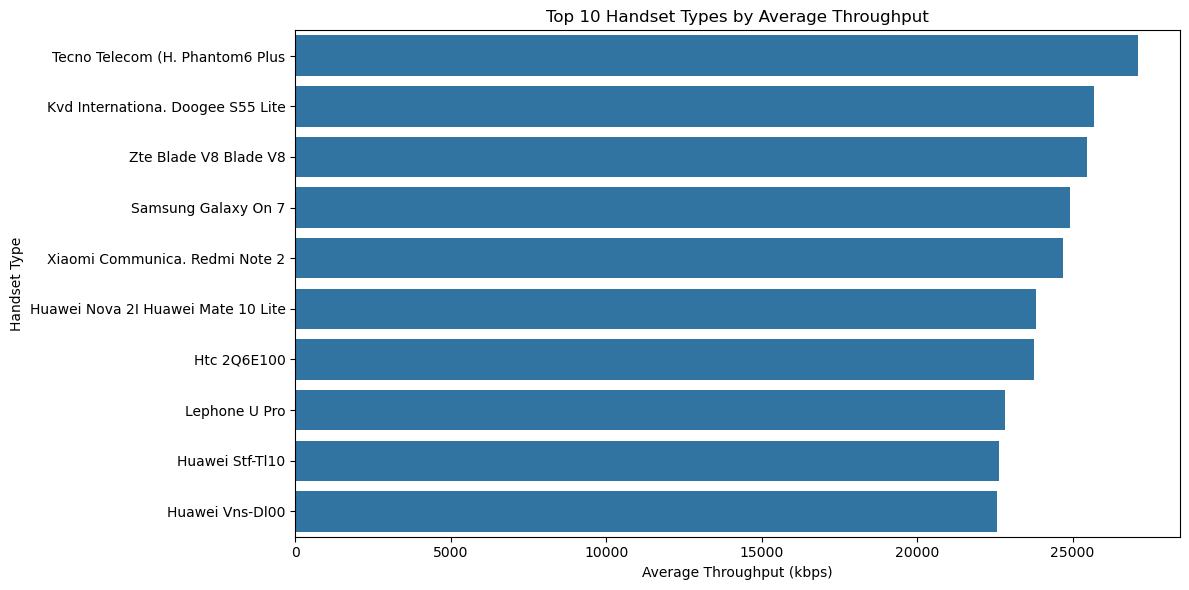

In [35]:
top10_throughput_handsets = (
    throughput_by_handset
    .sort_values(
        "Average_Throughput",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top10_throughput_handsets,
    x="Average_Throughput",
    y="Handset_Type"
)

plt.title(
    "Top 10 Handset Types by Average Throughput"
)

plt.xlabel("Average Throughput (kbps)")
plt.ylabel("Handset Type")

plt.tight_layout()
plt.show()

### Insight
+ The highest average throughput is recorded for Tecno Telecom (H. Phantom6 Plus) at approximately 27,100 kbps. It is followed by Kvd Internationa. Doogee S55 Lite and Zte Blade V8 Blade V8, both around 25,500 kbps.
+ Overall, the top 10 handset types have relatively high and fairly similar average throughput, ranging from approximately 22,700 to 27,100 kbps. This suggests that users of these handset models generally experienced better data transmission speeds compared with lower-throughput handset groups.
+ The Tecno Telecom (H. Phantom6 Plus) shows the highest average throughput among the displayed handset types, while Huawei Vns-Dl00 has the lowest within this top-10 group.

### Bottom 10 Handset by Throughput

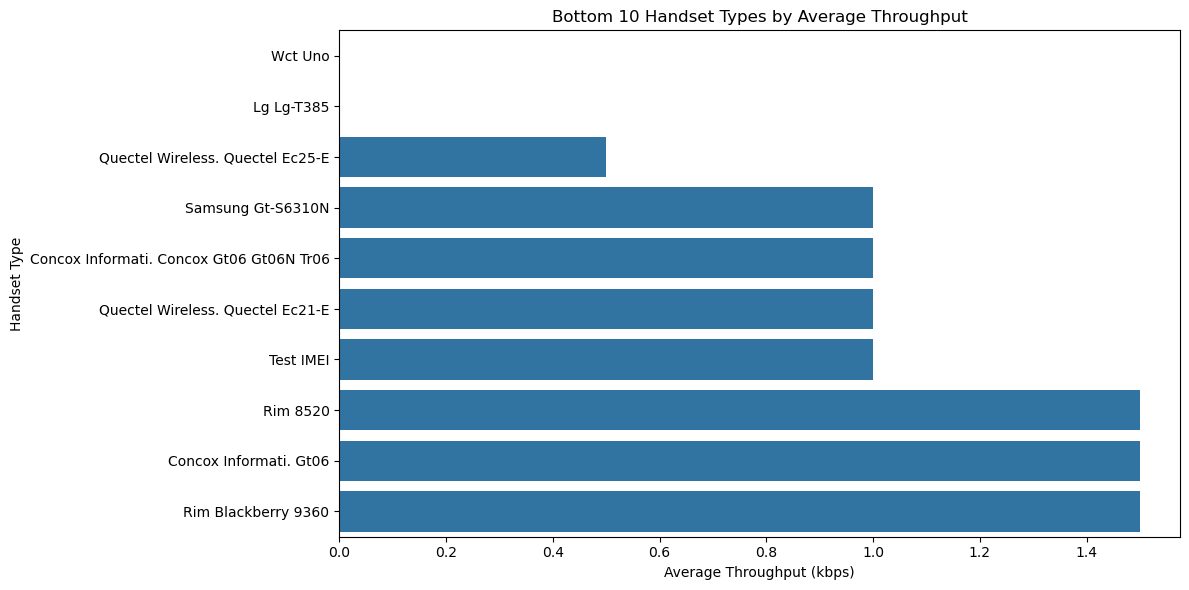

In [36]:
bottom10_throughput_handsets = (
    throughput_by_handset
    .sort_values(
        "Average_Throughput",
        ascending=True
    )
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=bottom10_throughput_handsets,
    x="Average_Throughput",
    y="Handset_Type"
)

plt.title(
    "Bottom 10 Handset Types by Average Throughput"
)

plt.xlabel("Average Throughput (kbps)")
plt.ylabel("Handset Type")

plt.tight_layout()
plt.show()

### Insight
+  The chart shows the bottom 10 handsets type by average throughput. Most of these handsets have an average throughput of approximately 1 kbps or lower, indicating very low data transmission performance.
+ Wct Uno and Lg Lg-T385 have almost 0 kbps average throughput. Quectel Wireless. Quectel Ec25-E has around 0.5 kbps, which is also extremely low.
Several handsets, including Samsung Gt-S6310N, Concox Informati. Concox Gt06 Gt06N Tr06, Quectel Wireless. Quectel Ec21-E, and Test IMEI, are close to 1 kbps.
+ The highest among this bottom group are Rim 8520, Concox Informati. Gt06, and Rim Blackberry 9360, at around 1.5 kbps.
+ Overall, these handset types show extremely low average throughput, suggesting that users associated with these devices experienced very limited data transmission speeds. The large gap between these handsets and the top-throughput handsets indicates substantial variation in user experience across handset types.

### Overall Interpretation
The distribution shows substantial variation in average throughput across handset types. The top 10 handset types achieve approximately 22,700–27,100 kbps, whereas the bottom 10 mostly record throughput below 1.5 kbps. This indicates significant differences in observed data transmission performance across handset types. However, handset type is only one possible factor influencing throughput, and network conditions and user behavior may also contribute to these differences.

##  TCP Retransmission by Handset

In [37]:
tcp_by_handset = (
    experience_user_df
    .groupby("Handset_Type")
    .agg(
        Average_TCP_Retransmission=(
            "Average_TCP_Retransmission",
            "mean"
        ),
        Customer_Count=(
            "MSISDN/Number",
            "count"
        )
    )
    .reset_index()
)

In [38]:
tcp_by_handset.sort_values(
    "Average_TCP_Retransmission",
    ascending=False
).head(20)

,Handset_Type,Average_TCP_Retransmission,Customer_Count
856,Samsung Galaxy Core 2 (Sm-G355X),2.327950e+07,1
2,A-Link Telecom I. Cubot Note S,2.070587e+07,1
1390,Zyxel Communicat. Lte7460,2.063827e+07,1
1153,Spa Condor Elect. Allure M1 Plus,1.588508e+07,1
800,Quartel Infotech. Maximus M84,1.564691e+07,2
1196,Tcl Communicatio. Pixi 4 6 3G Android,1.543098e+07,4
620,Lg-M400Dy,1.420619e+07,1
142,Asustek Asus Zenfone Selfie Zd551Kl,1.381255e+07,2
573,Lg G6+,1.353974e+07,1
877,Samsung Galaxy J3 (Sm-J327),1.268490e+07,1


### Top 10 TCP Retransmission Handsets

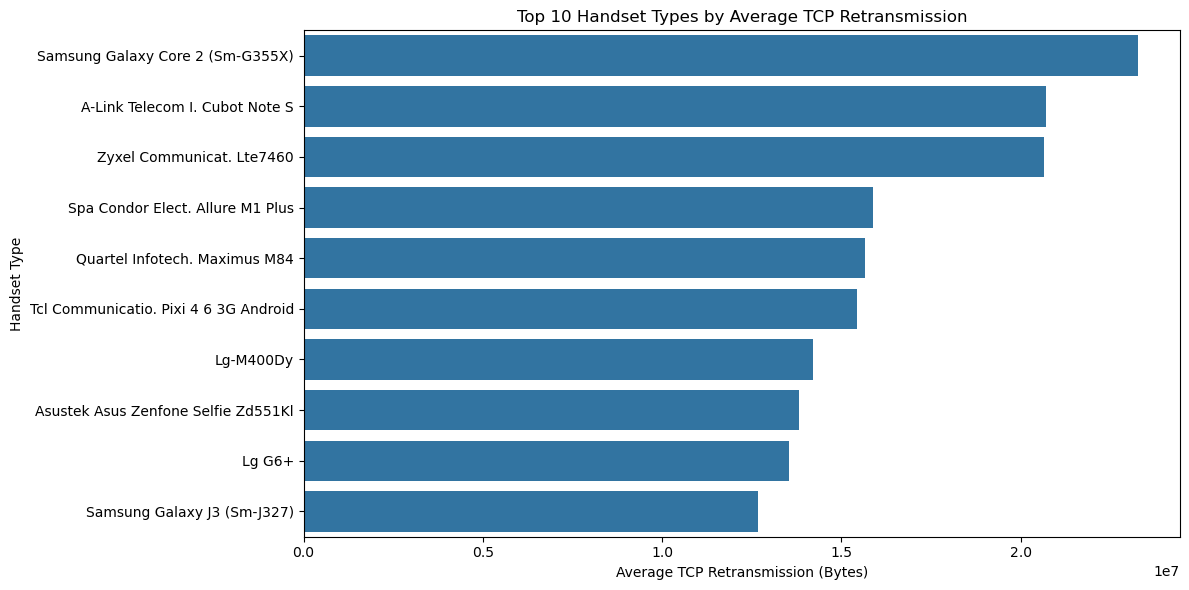

In [39]:
top10_tcp_handsets = (
    tcp_by_handset
    .sort_values(
        "Average_TCP_Retransmission",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top10_tcp_handsets,
    x="Average_TCP_Retransmission",
    y="Handset_Type"
)

plt.title(
    "Top 10 Handset Types by Average TCP Retransmission"
)

plt.xlabel("Average TCP Retransmission (Bytes)")
plt.ylabel("Handset Type")

plt.tight_layout()
plt.show()

### Insight
+ Samsung Galaxy Core 2 (Sm-G355X) has the highest average TCP retransmission, at approximately 23 million bytes.
+ A-Link Telecom I. Cubot Note S and Zyxel Communicat. Lte7460 follow, with values around 20–21 million bytes.
+ The remaining handset types have average TCP retransmission values between approximately 12.7 and 16 million bytes. There is a noticeable difference between the highest handset and the rest, indicating that the Samsung Galaxy Core 2 has particularly high retransmission compared with the other handsets shown.
+ Overall, higher TCP retransmission indicates that more data had to be retransmitted during transmission, which can be associated with less efficient data delivery and potentially poorer network experience. The results show considerable variation in TCP retransmission across handset types, suggesting differences in observed network performance among device groups.

### Bottom 10 TCP Retransmission Handsets

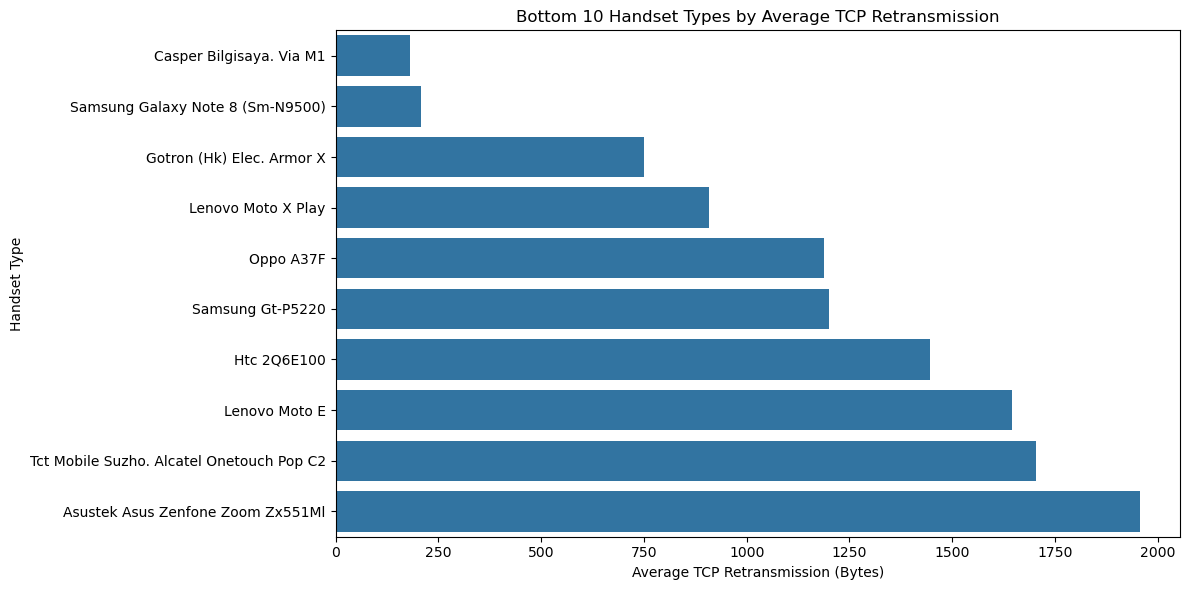

In [40]:
bottom10_tcp_handsets = (
    tcp_by_handset
    .sort_values(
        "Average_TCP_Retransmission",
        ascending=True
    )
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=bottom10_tcp_handsets,
    x="Average_TCP_Retransmission",
    y="Handset_Type"
)

plt.title(
    "Bottom 10 Handset Types by Average TCP Retransmission"
)

plt.xlabel("Average TCP Retransmission (Bytes)")
plt.ylabel("Handset Type")

plt.tight_layout()
plt.show()

### Insight
+ Casper Bilgisaya. Via M1 has the lowest average TCP retransmission, at approximately 180 bytes. Samsung Galaxy Note 8 (Sm-N9500) follows at around 200 bytes.
+ The remaining handset types range from approximately 750 to 1,950 bytes.
+ Asustek Asus Zenfone Zoom Zx551Ml has the highest retransmission within this bottom-10 group, at approximately 1,950 bytes.
+ Overall these handset types have relatively low TCP retransmission compared with the top-retransmission handset types. Lower retransmission generally indicates more efficient data transmission with fewer retransmitted bytes. The wide range even within this bottom group shows that TCP retransmission varies considerably across handset models.

## K-Means Clustering

In [41]:
experience_metrics = [
    "Average_TCP_Retransmission",
    "Average_RTT",
    "Average_Throughput"
]

X_experience = experience_user_df[
    experience_metrics
].copy()

In [42]:
X_experience.describe()

,Average_TCP_Retransmission,Average_RTT,Average_Throughput
count,1.068570e+05,106857.000000,106857.000000
mean,7.368027e+06,39.066952,3777.627484
std,4.486037e+06,22.243199,6165.713506
min,4.850000e+01,0.000000,0.000000
25%,2.645721e+06,20.250000,46.000000
50%,1.078479e+07,34.000000,105.500000
75%,1.078479e+07,63.000000,4522.000000
max,2.580578e+07,129.000000,27866.000000


### Insight
+ Average TCP Retransmission has a mean of approximately 7.37 million bytes, with values ranging from 48.5 bytes to 25.81 million bytes. The high standard deviation of 4.49 million indicates considerable variation in retransmission levels.
+ Average RTT has a mean of 39.07 ms, ranging from 0 to 129 ms. The median is 34 ms, showing that most customers have relatively moderate RTT values, although some customers experience higher latency.
+ Average Throughput has a mean of approximately 3,777.63 kbps, but ranges from 0 to 27,866 kbps. The median is only 105.5 kbps, much lower than the mean, indicating a highly right-skewed distribution with some customers having substantially higher throughput.

Overall insight: The large ranges and differences between the mean and median, particularly for Average Throughput and TCP Retransmission, show that customer experience varies considerably. These differences justify using standardization before K-Means clustering so that metrics with larger numerical scales do not dominate the clustering process.

### Standardize the Variables

In [43]:
experience_scaler = StandardScaler()

X_experience_scaled = experience_scaler.fit_transform(
    X_experience
)

In [44]:
X_experience_scaled[:5]

array([[ 0.76164673, -0.72233435, -0.60652266],
       [ 0.76164673, -1.05951764, -0.6046575 ],
       [ 0.76164673,  1.10876399, -0.60481969],
       [-1.55765473,  0.13186332, -0.5925745 ],
       [ 0.08182636, -0.41886939, -0.26671818]])

### Insight
+ The experience variables were standardized so that TCP retransmission, RTT, and throughput are placed on a comparable scale. This prevents variables with larger numerical values, such as TCP retransmission, from disproportionately influencing the K-Means clustering results.

### Run K-Means with k=3

In [45]:
experience_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

experience_user_df["Experience_Cluster"] = (
    experience_kmeans.fit_predict(
        X_experience_scaled
    )
)

In [46]:
experience_user_df[
    "Experience_Cluster"
].value_counts().sort_index()

Experience_Cluster
0    34652
1    45450
2    26755
Name: count, dtype: int64

### Insight
+ The K-Means clustering divided the 106,857 customers into three experience clusters. Cluster 1 contains the largest group with 45,450 customers (42.5%), followed by Cluster 0 with 34,652 customers (32.4%), while Cluster 2 contains 26,755 customers (25.0%). This shows that the customer base is distributed across the three experience groups, with Cluster 1 representing the largest segment.

### Cluster Centers

In [48]:
experience_cluster_centers = pd.DataFrame(
    experience_scaler.inverse_transform(
        experience_kmeans.cluster_centers_
    ),
    columns=experience_metrics
)

experience_cluster_centers.index.name = "Experience_Cluster"

experience_cluster_centers

,Average_TCP_Retransmission,Average_RTT,Average_Throughput
Experience_Cluster,,,
0,1.903495e+06,39.867534,9781.489894
1,1.017060e+07,22.395020,728.654538
2,9.677041e+06,66.353018,1189.406750


### Insight
+ The cluster centers show clear differences in user experience across the three clusters. Cluster 0 has the lowest average TCP retransmission (1.90 million bytes) and the highest average throughput (9,781 kbps), although its RTT is moderate at 39.87 ms.
+ Cluster 1 has the highest TCP retransmission (10.17 million bytes) and low throughput (729 kbps), but the lowest RTT at 22.40 ms.
+ Cluster 2 has high TCP retransmission (9.68 million bytes), the highest RTT (66.35 ms), and low throughput of 1,189 kbps.
+ Overall, the clusters show distinct combinations of retransmission, latency, and throughput, providing a basis for categorizing users into different experience groups.

### Identify Experience Group

In [49]:
experience_cluster_centers_scaled_df = pd.DataFrame(
    experience_kmeans.cluster_centers_,
    columns=experience_metrics
)

In [50]:
experience_cluster_centers_scaled_df["Experience_Index"] = (
    -experience_cluster_centers_scaled_df[
        "Average_TCP_Retransmission"
    ]
    -
    experience_cluster_centers_scaled_df[
        "Average_RTT"
    ]
    +
    experience_cluster_centers_scaled_df[
        "Average_Throughput"
    ]
)

In [51]:
experience_cluster_centers_scaled_df

,Average_TCP_Retransmission,Average_RTT,Average_Throughput,Experience_Index
0,-1.218126,0.035992,0.973754,2.155888
1,0.624736,-0.749533,-0.494507,-0.369710
2,0.514714,1.226721,-0.419778,-2.161213


### Insight
+ The Experience Index clearly differentiates the three clusters. Cluster 0 has the highest index (2.16), reflecting its combination of low TCP retransmission and high throughput.
+ Cluster 1 has a moderate index (-0.37), reflecting high TCP retransmission and low throughput, despite having relatively low RTT.
+ Cluster 2 has the lowest index (-2.16), driven by high TCP retransmission, the highest RTT, and low throughput. Therefore, the index provides a useful basis for distinguishing the three experience profiles.

In [52]:
cluster_order = (
    experience_cluster_centers_scaled_df[
        "Experience_Index"
    ]
    .rank(method="first")
)

In [53]:
experience_labels = {}

for cluster, rank in cluster_order.items():
    
    if rank == 1:
        experience_labels[cluster] = "Poor Experience"
        
    elif rank == 2:
        experience_labels[cluster] = "Moderate Experience"
        
    else:
        experience_labels[cluster] = "Good Experience"

In [54]:
experience_user_df["Experience_Level"] = (
    experience_user_df[
        "Experience_Cluster"
    ].map(experience_labels)
)

In [55]:
experience_user_df[
    [
        "MSISDN/Number",
        "Average_TCP_Retransmission",
        "Average_RTT",
        "Average_Throughput",
        "Experience_Cluster",
        "Experience_Level"
    ]
].head()

,MSISDN/Number,Average_TCP_Retransmission,Average_RTT,Average_Throughput,Experience_Cluster,Experience_Level
0,33601001722.0,1.078479e+07,23.000000,38.000000,1,Moderate Experience
1,33601001754.0,1.078479e+07,15.500000,49.500000,1,Moderate Experience
2,33601002511.0,1.078479e+07,63.729294,48.500000,2,Poor Experience
3,33601007832.0,3.803623e+05,42.000000,124.000000,0,Good Experience
4,33601008617.0,7.735101e+06,29.750000,2133.127286,1,Moderate Experience


### Cluster Summary

In [57]:
experience_cluster_summary = (
    experience_user_df
    .groupby(
        [
            "Experience_Cluster",
            "Experience_Level"
        ]
    )
    .agg(
        Customer_Count=(
            "MSISDN/Number",
            "count"
        ),
        
        TCP_Min=(
            "Average_TCP_Retransmission",
            "min"
        ),
        
        TCP_Average=(
            "Average_TCP_Retransmission",
            "mean"
        ),
        
        TCP_Max=(
            "Average_TCP_Retransmission",
            "max"
        ),
        
        RTT_Min=(
            "Average_RTT",
            "min"
        ),
        
        RTT_Average=(
            "Average_RTT",
            "mean"
        ),
        
        RTT_Max=(
            "Average_RTT",
            "max"
        ),
        
        Throughput_Min=(
            "Average_Throughput",
            "min"
        ),
        
        Throughput_Average=(
            "Average_Throughput",
            "mean"
        ),
        
        Throughput_Max=(
            "Average_Throughput",
            "max"
        )
    )
    .reset_index()
)

experience_cluster_summary

,Experience_Cluster,Experience_Level,Customer_Count,TCP_Min,TCP_Average,TCP_Max,RTT_Min,RTT_Average,RTT_Max,Throughput_Min,Throughput_Average,Throughput_Max
0,0,Good Experience,34652,48.5,1.906972e+06,18998514.5,8.0,39.842473,129.0,0.5,9775.908548,27866.0
1,1,Moderate Experience,45450,1854576.5,1.017223e+07,25742719.5,0.0,22.396859,47.5,0.0,725.899511,26196.0
2,2,Poor Experience,26755,91.0,9.677332e+06,25805777.5,43.0,66.380813,129.0,0.0,1193.011559,27866.0


### Insight
+ The cluster summary shows three distinct customer experience groups. Cluster 0 (Good Experience) contains 34,652 customers and has the lowest average TCP retransmission (1.91 million bytes) and the highest average throughput (9,775.91 kbps), indicating relatively efficient data transmission. Its average RTT is 39.84 ms.

+ Cluster 1 (Moderate Experience) is the largest group, with 45,450 customers. It has a relatively high average TCP retransmission of 10.17 million bytes and a low average throughput of 725.90 kbps. However, it has the lowest average RTT (22.40 ms) among the three clusters.

+ Cluster 2 (Poor Experience) contains 26,755 customers. It has high average TCP retransmission (9.68 million bytes), the highest average RTT (66.38 ms), and low average throughput (1,193.01 kbps). The combination of high retransmission and latency with relatively low throughput represents the least favorable experience profile among the three clusters.

Overall: The clustering identifies clear differences in user experience based on TCP retransmission, RTT, and throughput. Cluster 0 is characterized by high throughput and low retransmission, Cluster 1 by low throughput and high retransmission but low RTT, and Cluster 2 by high latency and retransmission with low throughput.

### Visualization of Clusters

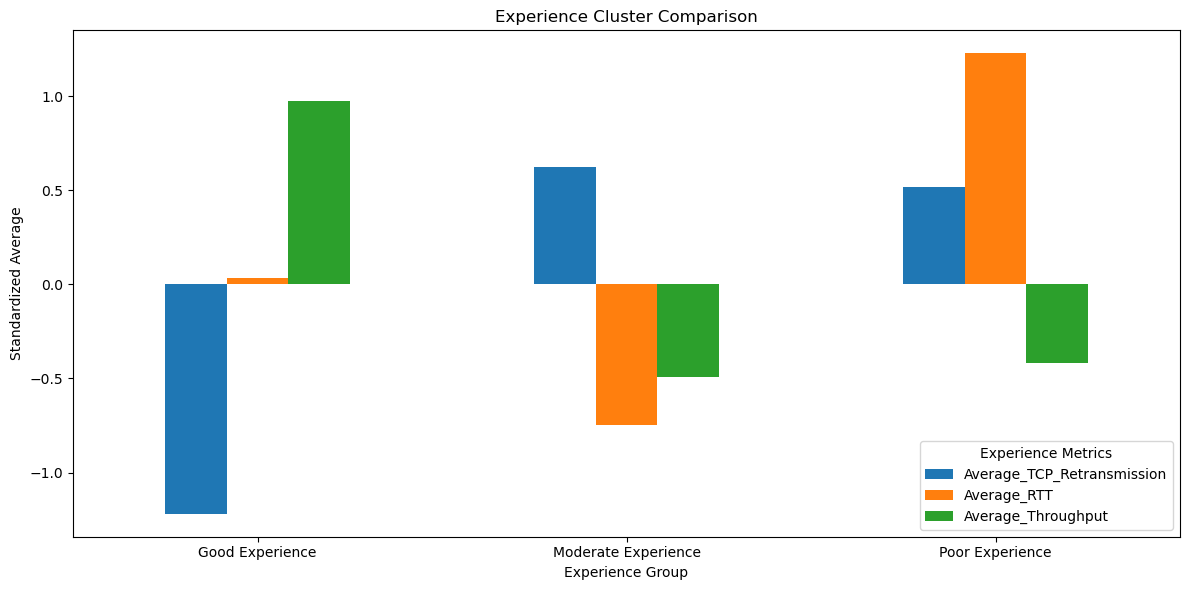

In [58]:
cluster_plot_data = (
    experience_cluster_centers_scaled_df[
        experience_metrics
    ]
    .copy()
)

cluster_plot_data.index = [
    experience_labels[i]
    for i in cluster_plot_data.index
]

cluster_plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Experience Cluster Comparison"
)

plt.xlabel("Experience Group")
plt.ylabel("Standardized Average")

plt.xticks(rotation=0)

plt.legend(
    title="Experience Metrics"
)

plt.tight_layout()
plt.show()

### Insight
+ The standardized cluster comparison shows clear differences between the three experience groups.
+ Good Experience is characterized by low TCP retransmission and high throughput, while RTT is close to the overall average.
+ Moderate Experience shows higher TCP retransmission and lower throughput, but relatively low RTT.
+ Poor Experience has higher TCP retransmission and RTT, combined with lower throughput.
+ Overall, the chart confirms that the three clusters have distinct experience patterns based on the selected network performance metrics.

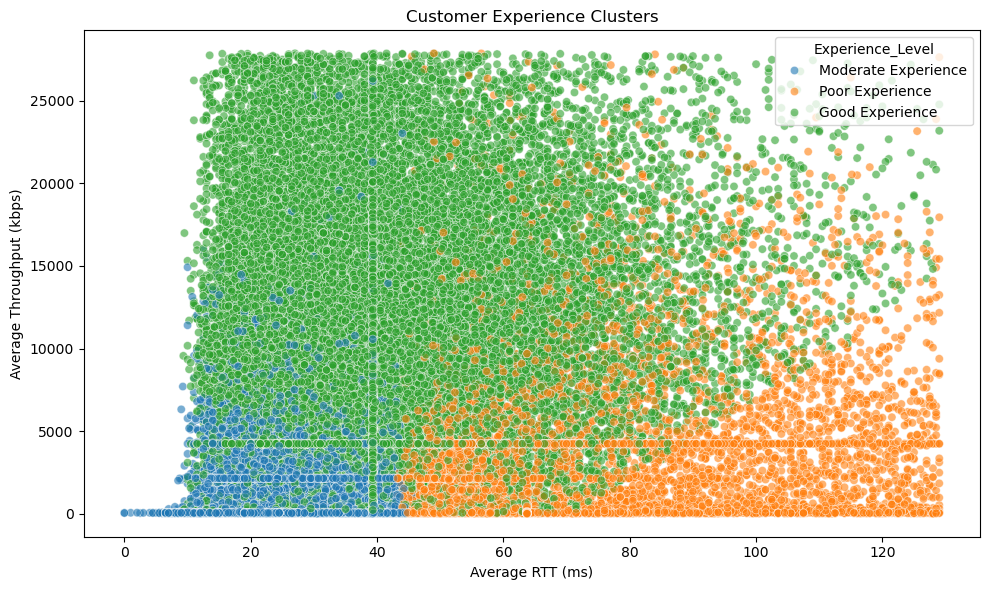

In [59]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=experience_user_df,
    x="Average_RTT",
    y="Average_Throughput",
    hue="Experience_Level",
    alpha=0.6
)

plt.title(
    "Customer Experience Clusters"
)

plt.xlabel("Average RTT (ms)")
plt.ylabel("Average Throughput (kbps)")

plt.tight_layout()
plt.show()

### Insight
+ The scatter plot shows a clear relationship between Average RTT and Average Throughput across the three experience groups. Good Experience customers are concentrated mainly in the lower-to-moderate RTT range and higher throughput levels, indicating better overall network performance.
+ Moderate Experience customers are more widely distributed, with generally lower throughput and moderate RTT values.
+ Poor Experience customers are concentrated more heavily at higher RTT values and lower throughput levels, indicating comparatively weaker network performance.
+ Overall, the visualization supports the K-Means segmentation: higher throughput and lower RTT are generally associated with better experience, while lower throughput and higher RTT are associated with poorer experience. The overlap between groups also shows that the experience categories are not completely separated, which is expected when customer network experience varies continuously.

### TCP vs Throughput

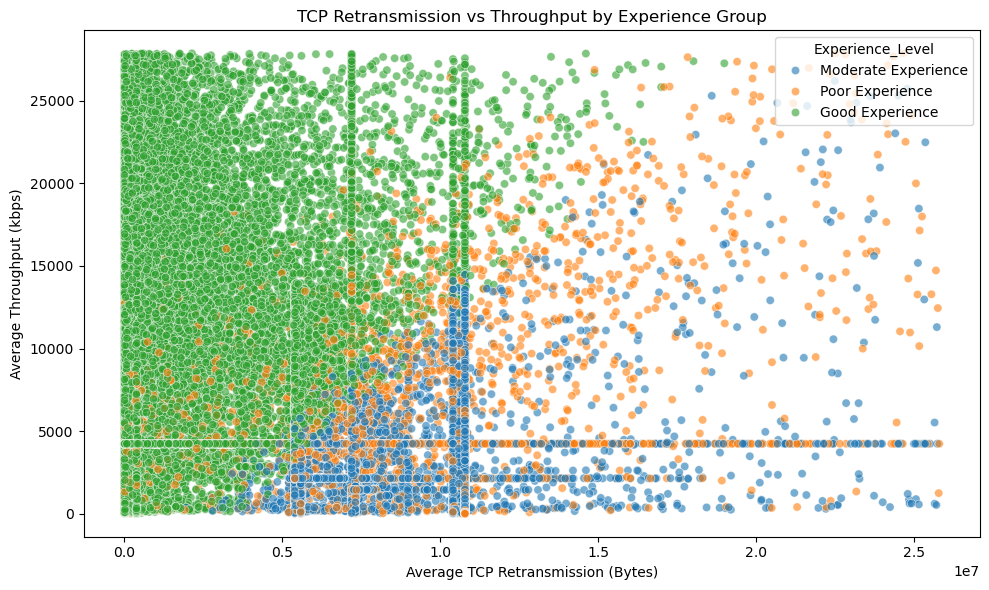

In [61]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=experience_user_df,
    x="Average_TCP_Retransmission",
    y="Average_Throughput",
    hue="Experience_Level",
    alpha=0.6
)

plt.title(
    "TCP Retransmission vs Throughput by Experience Group"
)

plt.xlabel("Average TCP Retransmission (Bytes)")
plt.ylabel("Average Throughput (kbps)")

plt.tight_layout()
plt.show()

### Insight
+ The scatter plot shows clear differences between the three experience groups. Good Experience customers are concentrated mainly in the region of lower TCP retransmission and higher throughput, indicating more efficient data transmission.
+ Poor Experience customers are more concentrated at higher TCP retransmission and lower throughput, reflecting less efficient transmission performance.
+ Moderate Experience customers are distributed between these two patterns, showing a wider range of TCP retransmission and throughput values.
+ Overall, the visualization supports the cluster interpretation: lower TCP retransmission combined with higher throughput is generally associated with better experience, while higher retransmission and lower throughput are associated with poorer experience. There is some overlap between the groups, indicating that no single metric completely determines the experience classification.

### Customers in each Experience Group

In [62]:
experience_user_df[
    "Experience_Level"
].value_counts()

Experience_Level
Moderate Experience    45450
Good Experience        34652
Poor Experience        26755
Name: count, dtype: int64

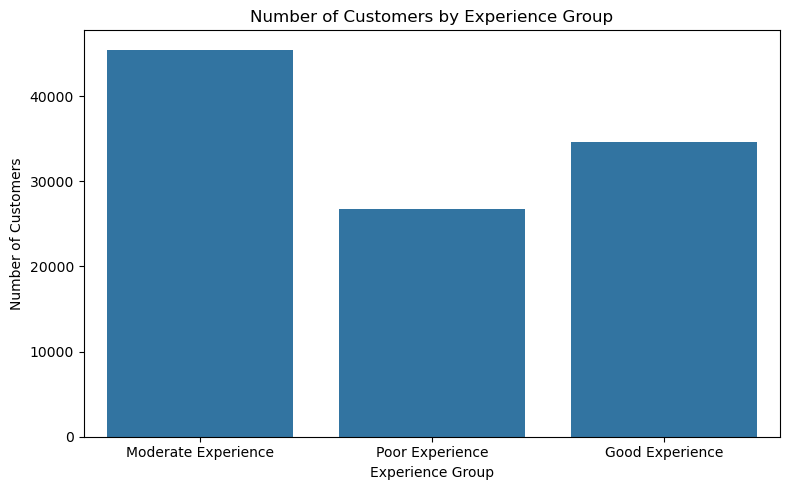

In [64]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=experience_user_df,
    x="Experience_Level"
)

plt.title(
    "Number of Customers by Experience Group"
)

plt.xlabel("Experience Group")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Insight
+ The customer distribution is divided across three experience groups. Moderate Experience is the largest group with 45,450 customers (42.5%), followed by Good Experience with 34,652 customers (32.4%). Poor Experience is the smallest group with 26,755 customers (25.0%).
+ Overall, the majority of customers (74.9%) fall into the Good or Moderate Experience groups, while 25.0% are classified as having Poor Experience. The distribution shows that the three clusters contain substantial customer populations rather than one cluster dominating the entire dataset.

## Final Experience Analysis Table

In [66]:
task3_final = experience_user_df[
    [
        "MSISDN/Number",
        "Handset_Type",
        "Average_TCP_Retransmission",
        "Average_RTT",
        "Average_Throughput",
        "Experience_Cluster",
        "Experience_Level"
    ]
].copy()

In [67]:
task3_final.head()

,MSISDN/Number,Handset_Type,Average_TCP_Retransmission,Average_RTT,Average_Throughput,Experience_Cluster,Experience_Level
0,33601001722.0,Huawei P20 Lite Huawei Nova 3E,1.078479e+07,23.000000,38.000000,1,Moderate Experience
1,33601001754.0,Apple iPhone 7 (A1778),1.078479e+07,15.500000,49.500000,1,Moderate Experience
2,33601002511.0,undefined,1.078479e+07,63.729294,48.500000,2,Poor Experience
3,33601007832.0,Apple iPhone 5S (A1457),3.803623e+05,42.000000,124.000000,0,Good Experience
4,33601008617.0,Apple iPhone Se (A1723),7.735101e+06,29.750000,2133.127286,1,Moderate Experience


## Save Final Results

In [68]:
import os

os.makedirs(
    "task3_outputs",
    exist_ok=True
)

### Final Experience Analysis Dataset

In [69]:
task3_final.to_csv(
    "task3_outputs/task3_final_customer_experience.csv",
    index=False
)

In [70]:
experience_cluster_summary.to_csv(
    "task3_outputs/task3_experience_cluster_summary.csv",
    index=False
)

In [71]:
throughput_by_handset.to_csv(
    "task3_outputs/task3_throughput_by_handset.csv",
    index=False
)

In [72]:
tcp_by_handset.to_csv(
    "task3_outputs/task3_tcp_by_handset.csv",
    index=False
)

### Save K-Means Model

In [73]:
import joblib

experience_model_data = {
    "scaler": experience_scaler,
    "kmeans": experience_kmeans,
    "experience_metrics": experience_metrics,
    "experience_labels": experience_labels
}

joblib.dump(
    experience_model_data,
    "task3_outputs/experience_kmeans_model.joblib"
)

['task3_outputs/experience_kmeans_model.joblib']

## Conclusion from User Experience Analysis
+ The experience analysis evaluated customers based on TCP retransmission, RTT, throughput, and handset type. After handling missing values and controlling extreme observations, customer-level experience metrics were created and analyzed across different handset types.
+ The analysis showed substantial variation in network performance, with some handset types recording considerably higher throughput and others showing very low throughput or different levels of TCP retransmission.
+ Using K-Means clustering with three clusters, 106,857 customers were segmented into three distinct experience groups. Good Experience customers (34,652) were characterized by low TCP retransmission and high throughput. Moderate Experience customers (45,450) formed the largest group and showed high retransmission and relatively low throughput, but lower RTT. Poor Experience customers (26,755) showed high TCP retransmission, the highest RTT, and low throughput.
+ Overall, the clustering demonstrates that customers have distinct network experience patterns based on the selected experience metrics. The segmentation provides a useful foundation for the next stage of analysis, where engagement and experience metrics can be combined to further understand customer behavior and identify customer segments.